In [3]:
!rm -rf ~/.kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!kaggle datasets list

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [5]:
!kaggle competitions download -c dogs-vs-cats

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [41]:
(data, info) = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

train_data, test_data = data

In [7]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Flatten,Conv2D,MaxPool2D,BatchNormalization,Dropout
from keras import Sequential

In [8]:
import tensorflow as tf

def preprocess(image, label):
    image = tf.image.resize(image, (256, 256))
    image = image / 255.0 #normalization of the image
    return image, label

train_data = train_data.map(preprocess).batch(32)
test_data = test_data.map(preprocess).batch(32)

In [9]:
for image, label in train_data.take(1):
    print(image.shape)

(32, 256, 256, 3)


In [10]:
#creating a cnn model
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='valid',strides=2))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='valid',strides=2))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='valid',strides=2))

model.add(Flatten())

#fully connected layers
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [13]:
history=model.fit(train_data,epochs=10,validation_data=test_data)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.5704 - loss: 1.3003 - val_accuracy: 0.6337 - val_loss: 0.6596
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.6864 - loss: 0.6025 - val_accuracy: 0.7283 - val_loss: 0.5487
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 65s 112ms/step - accuracy: 0.7680 - loss: 0.4778 - val_accuracy: 0.7287 - val_loss: 0.5228
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.8091 - loss: 0.4082 - val_accuracy: 0.7874 - val_loss: 0.4553
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 66s 113ms/step - accuracy: 0.8474 - loss: 0.3463 - val_accuracy: 0.7883 - val_loss: 0.4785
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.8739 - loss: 0.2930 - val_accuracy: 0.7087 - val_loss: 0.8669
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 55s 94ms/step - accuracy: 0.9005 - loss: 0.2334 - val_accuracy: 0.7324 - val_loss: 0.6281
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 55s 94ms/step - accuracy: 0.9254 - loss: 0.1806

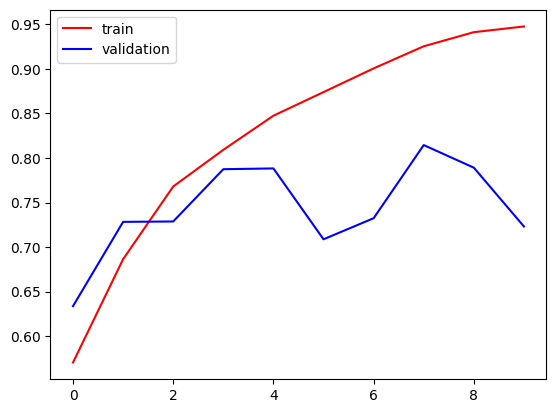

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

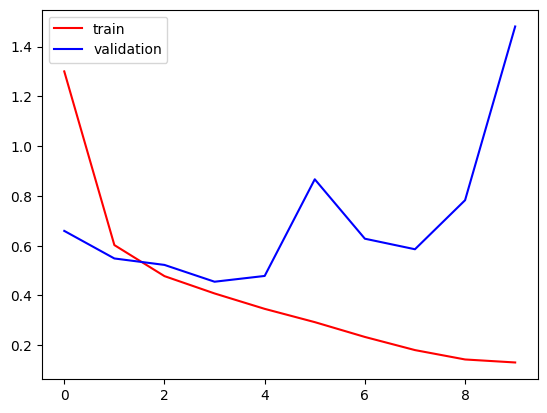

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

## from this graphs w can see that the model is prforming good on the training data but bad at the validation data that measn the model is facing the problem of overfitting

### there are multiple ways to reduce the overfitting and we will be trying out those methods to reduce the overfitting like L2/L1 Regularization,droput layers,batch norm,data augmentation,reduce complexity

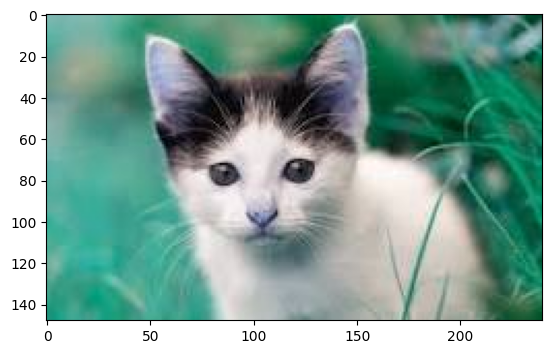

In [66]:
import cv2
test_image=cv2.imread('/content/cat.jpg')
plt.imshow(test_image)

In [67]:
test_image.shape

(148, 240, 3)

In [68]:
test_image=cv2.resize(test_image,(256,256))
test_image.shape

(256, 256, 3)

In [69]:
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

test_image = test_image / 255.0

test_input = test_image.reshape((1,256,256,3))

prediction = model.predict(test_input)

if prediction > 0.5:
    print("it is a dog")
else:
    print("it is a cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
it is a cat


In [42]:
print(info.features['label'].names)

['cat', 'dog']


In [64]:
print(prediction)

[[0.00074216]]


In [65]:
history.history['accuracy']
history.history['val_accuracy']

[0.6337059140205383,
 0.7282888889312744,
 0.7287188172340393,
 0.7874032855033875,
 0.7882631421089172,
 0.7087274193763733,
 0.7323731780052185,
 0.814488410949707,
 0.7891229391098022,
 0.7231298089027405]